
# Sumativa 1 — Informe Técnico de Avance del Proyecto

**Universidad Andrés Bello (UNAB)**  
**Magíster en Ciencia de Datos e Inteligencia Artificial**  
**Asignatura:** Estadística Computacional (MCDI501)  
**Equipo:** Grupo 7  
**Dataset:** Por confirmar  
**Fecha:** Octubre de 2026

---

## 1. Introducción

El presente notebook documenta el desarrollo de la primera evaluación sumativa de la asignatura Estadística Computacional, correspondiente al análisis exploratorio e inferencial de un conjunto de datos.

El propósito es aplicar técnicas estadísticas mediante Python, garantizando la reproducibilidad de los procedimientos, la interpretación de los resultados y la fundamentación de las conclusiones obtenidas.

### Objetivo general

Analizar un conjunto de datos mediante herramientas de estadística descriptiva e inferencial para identificar patrones, explorar relaciones entre variables y obtener conclusiones preliminares fundamentadas en evidencia cuantitativa.

### Objetivos específicos

1. Examinar la estructura, integridad y calidad del conjunto de datos.
2. Aplicar técnicas de estadística descriptiva y análisis exploratorio.
3. Identificar relaciones entre variables mediante análisis bivariado y visualizaciones.
4. Calcular estimaciones puntuales e intervalos de confianza del 95 % para al menos tres variables numéricas.
5. Formular y contrastar al menos dos hipótesis estadísticas pertinentes al problema.
6. Interpretar los resultados, reconocer sus limitaciones y establecer próximos pasos.

### Reproducibilidad

El análisis se desarrollará utilizando Python y bibliotecas especializadas en procesamiento, visualización e inferencia estadística. Se documentarán las decisiones metodológicas y se utilizarán semillas aleatorias fijas cuando corresponda.


In [14]:

# ============================================================
# SUMATIVA 1 - ESTADÍSTICA COMPUTACIONAL (MCDI501)
# Grupo 7 | Universidad Andrés Bello
# 2. Importación de bibliotecas y configuración del entorno
# ============================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística descriptiva e inferencial
from scipy import stats

# Configuración de reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración de visualizaciones
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

# Configuración de visualización de DataFrames
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

print("Entorno de análisis configurado correctamente.")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")


Entorno de análisis configurado correctamente.
Pandas: 3.0.6
NumPy: 2.5.3



## 3. Preparación y auditoría inicial de los datos

### 3.1. Objetivo

Esta etapa tiene como propósito cargar, examinar y preparar el conjunto de datos **E-Commerce Shipping**, asegurando su integridad, trazabilidad y reproducibilidad antes de aplicar técnicas de estadística descriptiva e inferencial.

Para ello, se implementa una arquitectura modular en Python, separando las responsabilidades de carga, validación y transformación de datos en funciones reutilizables ubicadas en el directorio `src/`.

### 3.2. Procedimiento metodológico

La preparación del conjunto de datos contempla las siguientes actividades:

1. **Carga de datos:** lectura del archivo CSV original mediante Pandas, conservando una copia sin modificaciones.

2. **Validación estructural:** verificación de las dimensiones del conjunto de datos, nombres de columnas, tipos de variables y presencia de los atributos requeridos.

3. **Auditoría de calidad:** identificación y cuantificación de valores faltantes, registros duplicados y posibles inconsistencias. Los hallazgos se documentarán antes de aplicar cualquier corrección.

4. **Generación controlada de valores faltantes:** de acuerdo con las instrucciones del curso, cuando el conjunto de datos no presente valores faltantes en variables numéricas, se implementará un mecanismo MCAR (*Missing Completely At Random*).

   Se propone introducir un 10 % de valores faltantes en las variables `Weight_in_gms` y `Cost_of_the_Product`, utilizando una semilla aleatoria fija (`random_state = 42`) para garantizar la reproducibilidad.

5. **Conservación y trazabilidad:** se mantendrán los datos originales y un registro de los valores eliminados artificialmente, permitiendo evaluar posteriormente los procedimientos de imputación.

6. **Persistencia de resultados:** se almacenará una versión preparada del conjunto de datos en `data/processed/`, sin sobrescribir el archivo original.

### 3.3. Criterios metodológicos

- **Reproducibilidad:** todas las transformaciones aleatorias utilizarán una semilla fija.
- **Integridad:** el conjunto de datos original permanecerá inalterado.
- **Trazabilidad:** las modificaciones podrán identificarse y auditarse.
- **Modularidad:** las operaciones de preparación se implementarán mediante funciones independientes y reutilizables.
- **Consistencia:** la versión preparada se utilizará como referencia para las siguientes etapas del proyecto, aplicando los tratamientos de datos faltantes que correspondan a cada análisis.

### 3.4. Resultado esperado

Al finalizar esta etapa, se dispondrá de un conjunto de datos estructurado, validado y documentado, acompañado de un diagnóstico de calidad y un registro de las transformaciones realizadas.

Esta preparación establecerá una base reproducible para el análisis exploratorio, la estimación de parámetros, la formulación de pruebas de hipótesis y las posteriores fases de modelamiento estadístico.

---


In [15]:
# ============================================================
# 3. PREPARACIÓN Y AUDITORÍA INICIAL — E-COMMERCE SHIPPING
# Notebook: notebooks/sumativa_1.ipynb
# ============================================================
from pathlib import Path
import sys
import pandas as pd

# Detectar la raíz del repositorio desde VS Code o Jupyter.
RAIZ = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src").is_dir() and (p / "requirements.txt").is_file()),
    None,
)
if RAIZ is None:
    raise RuntimeError("Abre VS Code en la carpeta raíz del repositorio.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.carga import cargar_csv, guardar_csv
from src.validacion import validar_esquema, informe_calidad, VARIABLES_NUMERICAS
from src.transformacion import generar_faltantes_mcar

RUTA_ORIGINAL = RAIZ / "data" / "raw" / "customer_analytics.csv"
RUTA_PREPARADO = RAIZ / "data" / "processed" / "ecommerce_mcar.csv"
RUTA_VERDAD = RAIZ / "data" / "processed" / "valores_originales_mcar.csv"

# 1) Carga y revisión del original; nunca se sobrescribe data/raw.
df_original = cargar_csv(RUTA_ORIGINAL)
validar_esquema(df_original)
print(f"Dataset original: {len(df_original):,} filas y {df_original.shape[1]} columnas")
print(f"Duplicados exactos: {df_original.duplicated().sum()}")
print("Auditoría inicial:")
display(informe_calidad(df_original))

# 2) La guía exige crear faltantes MCAR solo si no hay faltantes numéricos.
if df_original[list(VARIABLES_NUMERICAS)].isna().any().any():
    df = df_original.copy(deep=True)
    auditoria_mcar = pd.DataFrame(columns=["ID", "variable", "valor_original"])
    print("Se detectaron faltantes numéricos reales: NO se generan artificiales.")
else:
    df, auditoria_mcar = generar_faltantes_mcar(
        df_original,
        columnas=("Weight_in_gms", "Cost_of_the_Product"),
        proporcion=0.10,
        semilla=42,
    )
    print("Faltantes MCAR generados (10% por variable, semilla 42).")

# 3) Guardar productos derivados para futuras sumativas.
guardar_csv(df, RUTA_PREPARADO)
if not auditoria_mcar.empty:
    guardar_csv(auditoria_mcar, RUTA_VERDAD)

print("Auditoría posterior a la preparación:")
display(informe_calidad(df))
print(f"Datos preparados: {RUTA_PREPARADO.relative_to(RAIZ)}")
if not auditoria_mcar.empty:
    print(f"Valores originales protegidos: {RUTA_VERDAD.relative_to(RAIZ)}")
display(df.head())


Dataset original: 10,999 filas y 12 columnas
Duplicados exactos: 0
Auditoría inicial:


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
0,ID,int64,0,0.0,10999
1,Warehouse_block,str,0,0.0,5
2,Mode_of_Shipment,str,0,0.0,3
3,Customer_care_calls,int64,0,0.0,6
4,Customer_rating,int64,0,0.0,5
5,Cost_of_the_Product,int64,0,0.0,215
6,Prior_purchases,int64,0,0.0,8
7,Product_importance,str,0,0.0,3
8,Gender,str,0,0.0,2
9,Discount_offered,int64,0,0.0,65


Faltantes MCAR generados (10% por variable, semilla 42).
Auditoría posterior a la preparación:


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
0,ID,int64,0,0.0,10999
1,Warehouse_block,str,0,0.0,5
2,Mode_of_Shipment,str,0,0.0,3
3,Customer_care_calls,int64,0,0.0,6
4,Customer_rating,int64,0,0.0,5
5,Cost_of_the_Product,float64,1100,10.0,215
6,Prior_purchases,int64,0,0.0,8
7,Product_importance,str,0,0.0,3
8,Gender,str,0,0.0,2
9,Discount_offered,int64,0,0.0,65


Datos preparados: data\processed\ecommerce_mcar.csv
Valores originales protegidos: data\processed\valores_originales_mcar.csv


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177.0,3,low,F,44,1233.0,1
1,2,F,Flight,4,5,216.0,2,low,M,59,3088.0,1
2,3,A,Flight,2,2,183.0,4,low,M,48,3374.0,1
3,4,B,Flight,3,3,176.0,4,medium,M,10,1177.0,1
4,5,C,Flight,2,2,184.0,3,medium,F,46,2484.0,1


## 4. Controles complementarios y diccionario estadístico

Se presenta un cuadro resumen con el detalle de los campos incluidos en el dataset.

**Unidad de observación:** cada registro del dataset corresponde a un envío, el cual está identificado por el campo `ID`.
**Resultado:** `Reached.on.Time_Y.N = 1` significa que el producto **NO llegó a tiempo**; `0`, que llegó a tiempo.

| Campo | Tipo estadístico | Interpretación |
|---|---|---|
| ID | Identificador | Identificador del envío, no será considerado para estadísticas y correlaciones |
| Warehouse_block | Nominal | Bloque correspondiente a la división del almacén |
| Mode_of_Shipment | Nominal | Vía de envío del producto |
| Customer_care_calls | Conteo discreto | Número de llamadas para consultar por el envío |
| Customer_rating | Ordinal | Valoración realizada por la compañía hacia el cliente, siendo esta de 1 (peor) a 5 (mejor) |
| Cost_of_the_Product | Cuantitativa | Costo del producto en USD |
| Prior_purchases | Conteo discreto | Cantidad de compras realizadas anteriormente |
| Product_importance | Ordinal | Importancia del producto categorizada por la compañía |
| Gender | Nominal | Género del cliente |
| Discount_offered | Cuantitativa | Descuento ofrecido por el producto; no se especifica unidad de medida ni que sea porcentaje |
| Weight_in_gms | Cuantitativa | Peso del producto en gramos |
| Reached.on.Time_Y.N | Binaria | Indica si el producto llegó a tiempo o no, siendo 1: fuera de plazo y  0: a tiempo |

A continuación, se realiza una revisión de calidad de la base original: busca valores que podrían estar incorrectos, cuenta cuántos hay y muestra un resumen.

In [16]:
from IPython.display import display, Markdown

dominios = {
    "Mode_of_Shipment": {"Ship", "Flight", "Road"},
    "Product_importance": {"low", "medium", "high"},
    "Gender": {"F", "M"},
    "Customer_rating": {1, 2, 3, 4, 5},
    "Reached.on.Time_Y.N": {0, 1},
}
controles = []
for col, dominio in dominios.items():
    controles.append({"control": f"Dominio de {col}",
                      "casos": int((df_original[col].notna() & ~df_original[col].isin(dominio)).sum())})
for col in VARIABLES_NUMERICAS:
    x = df_original[col].dropna()
    controles.append({"control": f"Valores no finitos en {col}", "casos": int((~np.isfinite(x)).sum())})
for col in ["Customer_care_calls", "Prior_purchases", "Discount_offered"]:
    controles.append({"control": f"Negativos en {col}", "casos": int(df_original[col].lt(0).sum())})
for col in ["Customer_care_calls", "Prior_purchases"]:
    controles.append({"control": f"Conteos no enteros en {col}", "casos": int(df_original[col].dropna().mod(1).ne(0).sum())})
for col in ["Cost_of_the_Product", "Weight_in_gms"]:
    controles.append({"control": f"No positivos en {col}", "casos": int(df_original[col].le(0).sum())})
controles.extend([
    {"control": "Duplicados exactos", "casos": int(df_original.duplicated().sum())},
    {"control": "ID duplicado", "casos": int(df_original.ID.duplicated().sum())},
    {"control": "Bloque fuera de A–E descritos por la fuente",
     "casos": int((df_original.Warehouse_block.notna() & ~df_original.Warehouse_block.isin(list("ABCDE"))).sum())}
])
display(pd.DataFrame(controles))
display(df_original["Warehouse_block"].value_counts().rename("n").to_frame())
# Copia de trabajo: no modificar el original ni usar la verdad MCAR para imputar.
df_eda = df_original.copy(deep=True)
df_eda["Estado_entrega"] = df_eda["Reached.on.Time_Y.N"].map({0: "A tiempo", 1: "Fuera de plazo"})
display(Markdown("No se aplican correcciones automáticas: los controles se documentan y la categoría F se conserva. Los valores extremos se revisan; no se consideran errores por su sola magnitud."))

,control,casos
0,Dominio de Mode_of_Shipment,0
1,Dominio de Product_importance,0
2,Dominio de Gender,0
3,Dominio de Customer_rating,0
4,Dominio de Reached.on.Time_Y.N,0
5,Valores no finitos en Customer_care_calls,0
6,Valores no finitos en Customer_rating,0
7,Valores no finitos en Cost_of_the_Product,0
8,Valores no finitos en Prior_purchases,0
9,Valores no finitos en Discount_offered,0


,n
Warehouse_block,
F,3666
D,1834
A,1833
B,1833
C,1833


No se aplican correcciones automáticas: los controles se documentan y la categoría F se conserva. Los valores extremos se revisan; no se consideran errores por su sola magnitud.

## 5. Análisis exploratorio de datos

### 5.1. Variables cuantitativas
Se calculan media, mediana, todas las modas, desviación estándar muestral, varianza, cuartiles, rango e IQR. Los histogramas describen forma y concentración; los diagramas de caja muestran dispersión y valores extremos según 1,5 IQR. Ese criterio señala observaciones para revisión, no autoriza eliminarlas. Las frecuencias de la valoración ordinal se presentan en la sección siguiente.

,n válido,faltantes,media,mediana,modas,DE,varianza,mínimo,Q1,Q3,máximo,rango,IQR,"fuera 1,5 IQR"
variable,,,,,,,,,,,,,,
Customer_care_calls,10999,0,4.054,4.0,[4],1.141,1.303e+00,2,3.0,5.0,7,5,2.0,0
Cost_of_the_Product,10999,0,210.197,214.0,[245],48.063,2.310e+03,96,169.0,251.0,310,214,82.0,0
Prior_purchases,10999,0,3.568,3.0,[3],1.523,2.319e+00,2,3.0,4.0,10,8,1.0,1003
Discount_offered,10999,0,13.373,7.0,[10],16.206,2.626e+02,1,4.0,10.0,65,64,6.0,2209
Weight_in_gms,10999,0,3634.017,4149.0,[4883],1635.377,2.674e+06,1001,1839.5,5050.0,7846,6845,3210.5,0


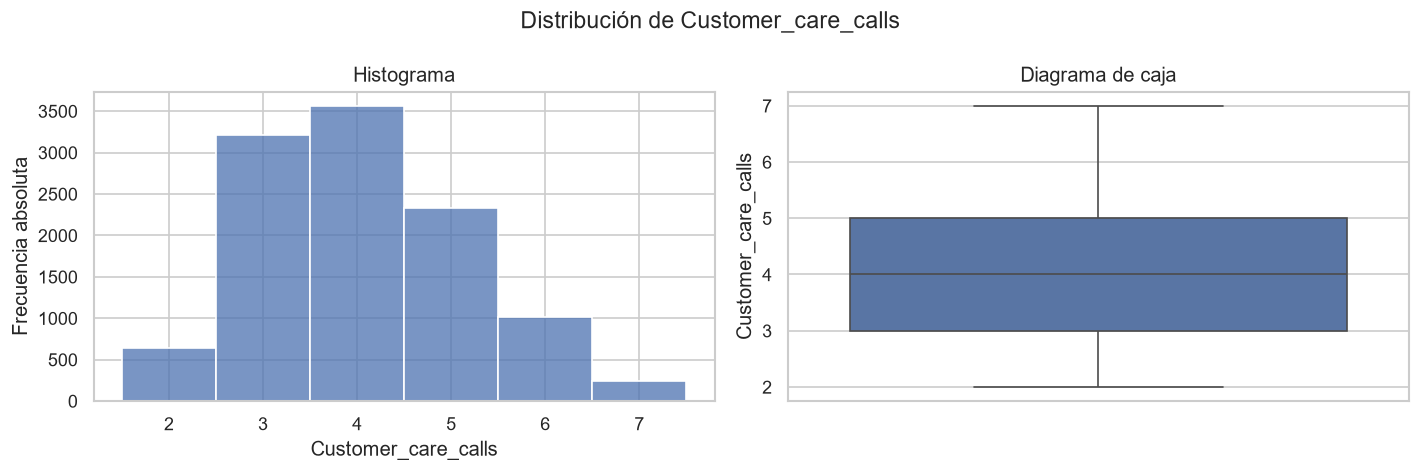

**Resumen de Customer_care_calls** — Unidad: llamadas.  
Se analizaron **10,999 valores válidos**, con **0 faltantes**. La media fue **4.05**, la mediana **4.00** y la(s) moda(s) **4**. La desviación estándar fue **1.14** y la varianza **1.30**. Los valores oscilaron entre **2.00** y **7.00**, con un rango de **5.00**. El 50 % central de los datos se ubicó entre **3.00** y **5.00**, con un rango intercuartílico de **2.00**. Se identificaron **0 valores** fuera de las cercas de 1,5 IQR; estos requieren revisión y no constituyen errores automáticamente.

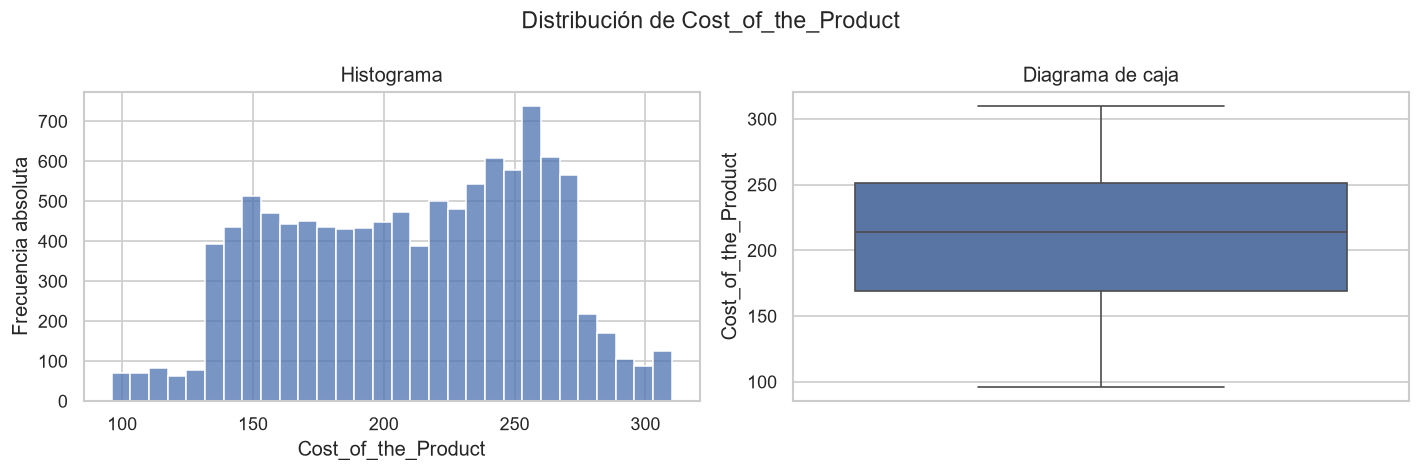

**Resumen de Cost_of_the_Product** — Unidad: USD.  
Se analizaron **10,999 valores válidos**, con **0 faltantes**. La media fue **210.20**, la mediana **214.00** y la(s) moda(s) **245**. La desviación estándar fue **48.06** y la varianza **2310.08**. Los valores oscilaron entre **96.00** y **310.00**, con un rango de **214.00**. El 50 % central de los datos se ubicó entre **169.00** y **251.00**, con un rango intercuartílico de **82.00**. Se identificaron **0 valores** fuera de las cercas de 1,5 IQR; estos requieren revisión y no constituyen errores automáticamente.

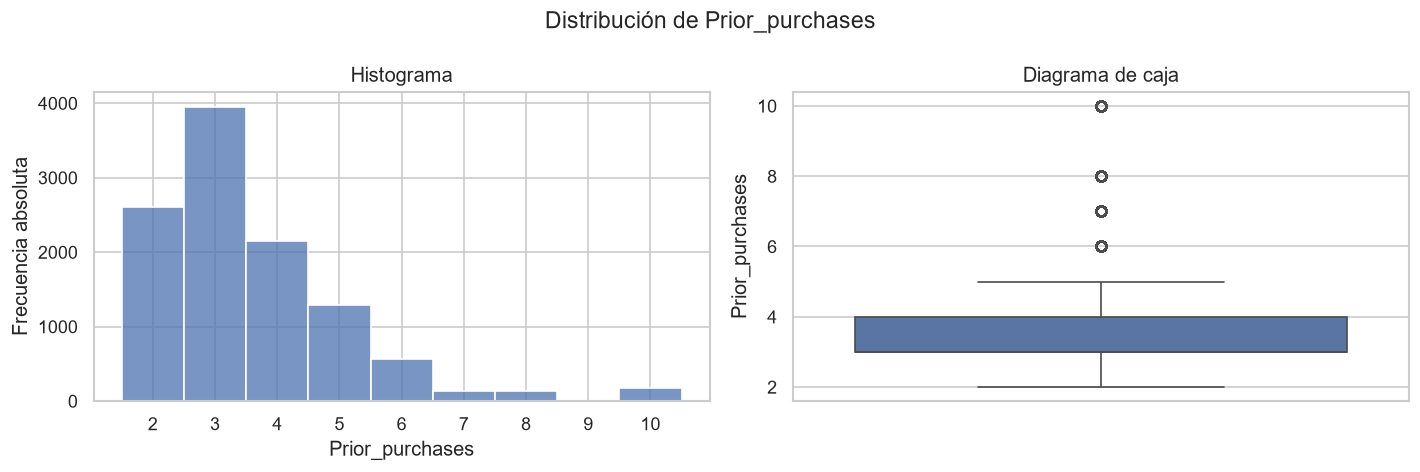

**Resumen de Prior_purchases** — Unidad: compras.  
Se analizaron **10,999 valores válidos**, con **0 faltantes**. La media fue **3.57**, la mediana **3.00** y la(s) moda(s) **3**. La desviación estándar fue **1.52** y la varianza **2.32**. Los valores oscilaron entre **2.00** y **10.00**, con un rango de **8.00**. El 50 % central de los datos se ubicó entre **3.00** y **4.00**, con un rango intercuartílico de **1.00**. Se identificaron **1,003 valores** fuera de las cercas de 1,5 IQR; estos requieren revisión y no constituyen errores automáticamente.

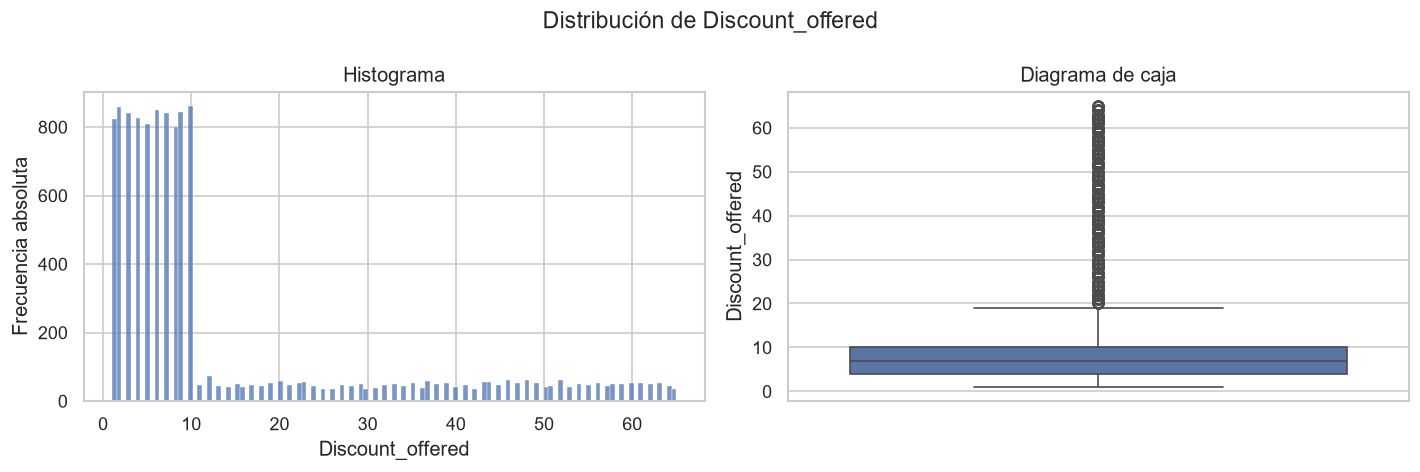

**Resumen de Discount_offered** — Unidad: unidad no especificada por la fuente.  
Se analizaron **10,999 valores válidos**, con **0 faltantes**. La media fue **13.37**, la mediana **7.00** y la(s) moda(s) **10**. La desviación estándar fue **16.21** y la varianza **262.62**. Los valores oscilaron entre **1.00** y **65.00**, con un rango de **64.00**. El 50 % central de los datos se ubicó entre **4.00** y **10.00**, con un rango intercuartílico de **6.00**. Se identificaron **2,209 valores** fuera de las cercas de 1,5 IQR; estos requieren revisión y no constituyen errores automáticamente.

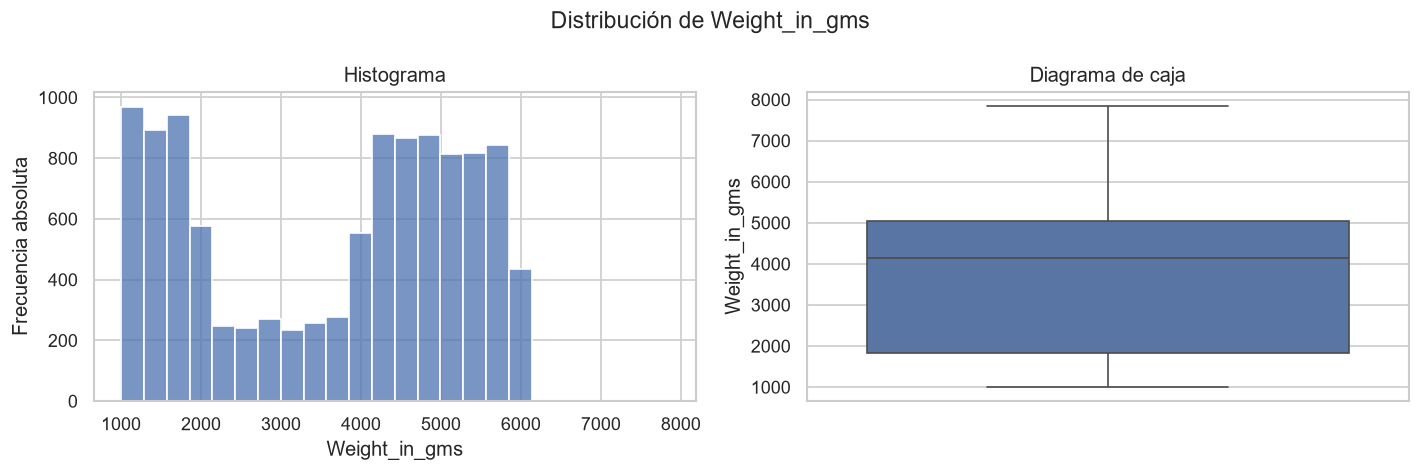

**Resumen de Weight_in_gms** — Unidad: gramos.  
Se analizaron **10,999 valores válidos**, con **0 faltantes**. La media fue **3634.02**, la mediana **4149.00** y la(s) moda(s) **4883**. La desviación estándar fue **1635.38** y la varianza **2674458.75**. Los valores oscilaron entre **1001.00** y **7846.00**, con un rango de **6845.00**. El 50 % central de los datos se ubicó entre **1839.50** y **5050.00**, con un rango intercuartílico de **3210.50**. Se identificaron **0 valores** fuera de las cercas de 1,5 IQR; estos requieren revisión y no constituyen errores automáticamente.

In [17]:
NUM = ["Customer_care_calls", "Cost_of_the_Product", "Prior_purchases", "Discount_offered", "Weight_in_gms"]
filas = []
for col in NUM:
    x = df_eda[col].dropna()
    q1, q3 = x.quantile([.25, .75]); iqr = q3-q1
    filas.append({"variable": col, "n válido": len(x), "faltantes": df_eda[col].isna().sum(),
                  "media": x.mean(), "mediana": x.median(), "modas": x.mode().tolist(),
                  "DE": x.std(ddof=1), "varianza": x.var(ddof=1), "mínimo": x.min(),
                  "Q1": q1, "Q3": q3, "máximo": x.max(), "rango": x.max()-x.min(),
                  "IQR": iqr, "fuera 1,5 IQR": int(((x<q1-1.5*iqr)|(x>q3+1.5*iqr)).sum())})
descriptivos = pd.DataFrame(filas).set_index("variable")
display(descriptivos)

# Variables de conteo: sus valores son números enteros.
DISCRETAS = {"Customer_care_calls", "Prior_purchases"}

UNIDADES = {
    "Customer_care_calls": "llamadas",
    "Cost_of_the_Product": "USD",
    "Prior_purchases": "compras",
    "Discount_offered": "unidad no especificada por la fuente",
    "Weight_in_gms": "gramos",
}

for col in NUM:
    x = df_eda[col].dropna()
    r = descriptivos.loc[col]

    # Una figura independiente para cada variable.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma: barras centradas en enteros para los conteos.
    if col in DISCRETAS:
        bins = np.arange(x.min() - 0.5, x.max() + 1.5, 1)

        sns.histplot(x=x, bins=bins, ax=axes[0])
        axes[0].set_xticks(
            np.arange(int(x.min()), int(x.max()) + 1)
        )
    else:
        sns.histplot(x=x, bins="auto", ax=axes[0])

    axes[0].set_title("Histograma")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia absoluta")

    # Diagrama de caja.
    sns.boxplot(y=x, ax=axes[1])
    axes[1].set_title("Diagrama de caja")
    axes[1].set_ylabel(col)
    axes[1].set_xlabel("")

    fig.suptitle(f"Distribución de {col}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Resumen debajo del par de gráficos.
    modas = ", ".join(f"{valor:g}" for valor in r["modas"])

    display(Markdown(
        f"**Resumen de {col}** — Unidad: {UNIDADES[col]}.  \n"
        f"Se analizaron **{int(r['n válido']):,} valores válidos**, "
        f"con **{int(r['faltantes']):,} faltantes**. "
        f"La media fue **{r['media']:.2f}**, "
        f"la mediana **{r['mediana']:.2f}** "
        f"y la(s) moda(s) **{modas}**. "
        f"La desviación estándar fue **{r['DE']:.2f}** "
        f"y la varianza **{r['varianza']:.2f}**. "
        f"Los valores oscilaron entre **{r['mínimo']:.2f}** "
        f"y **{r['máximo']:.2f}**, "
        f"con un rango de **{r['rango']:.2f}**. "
        f"El 50 % central de los datos se ubicó entre "
        f"**{r['Q1']:.2f}** y **{r['Q3']:.2f}**, "
        f"con un rango intercuartílico de **{r['IQR']:.2f}**. "
        f"Se identificaron **{int(r['fuera 1,5 IQR']):,} valores** "
        f"fuera de las cercas de 1,5 IQR; "
        f"estos requieren revisión y no constituyen errores automáticamente."
    ))

### 5.2. Variables categóricas y ordinales
Se presentan frecuencias absolutas, porcentajes sobre todos los registros y faltantes explícitos. Para la valoración y la importancia se respeta el orden de categorías. La puntualidad se interpreta conforme a la codificación de la fuente.

### Bloque del almacén

,Frecuencia absoluta,Frecuencia relativa (%)
Categoría,,
Bloque A,1833,16.67
Bloque B,1833,16.67
Bloque C,1833,16.67
Bloque D,1834,16.67
Bloque F,3666,33.33


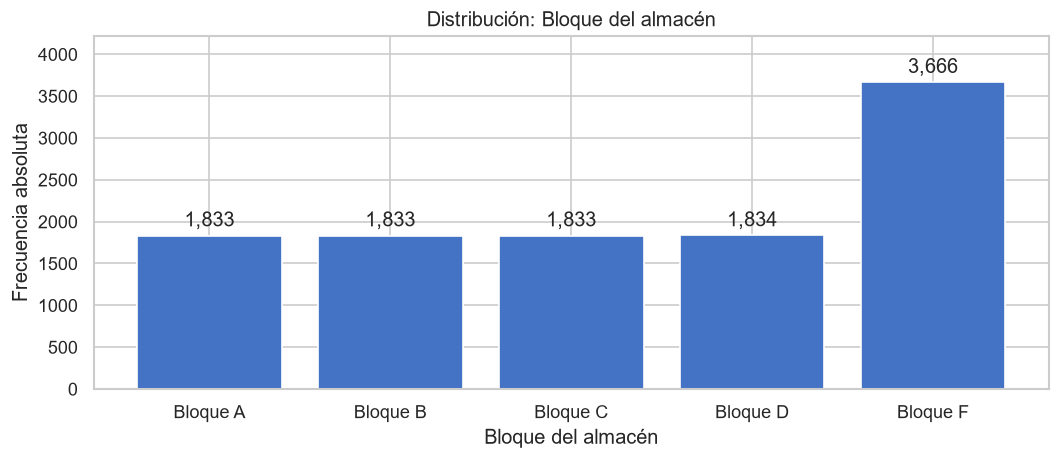

La categoría más frecuente es **Bloque F**, con **3,666 registros**, equivalentes al **33.33 %** del total.

### Modo de envío

,Frecuencia absoluta,Frecuencia relativa (%)
Categoría,,
Barco,7462,67.84
Avión,1777,16.16
Transporte terrestre,1760,16.00


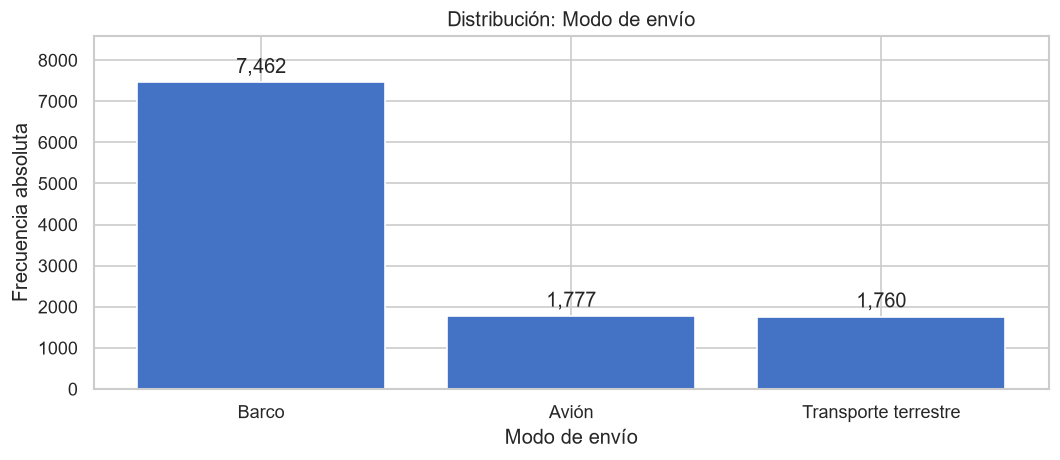

La categoría más frecuente es **Barco**, con **7,462 registros**, equivalentes al **67.84 %** del total.

### Importancia del producto

,Frecuencia absoluta,Frecuencia relativa (%)
Categoría,,
Baja,5297,48.16
Media,4754,43.22
Alta,948,8.62


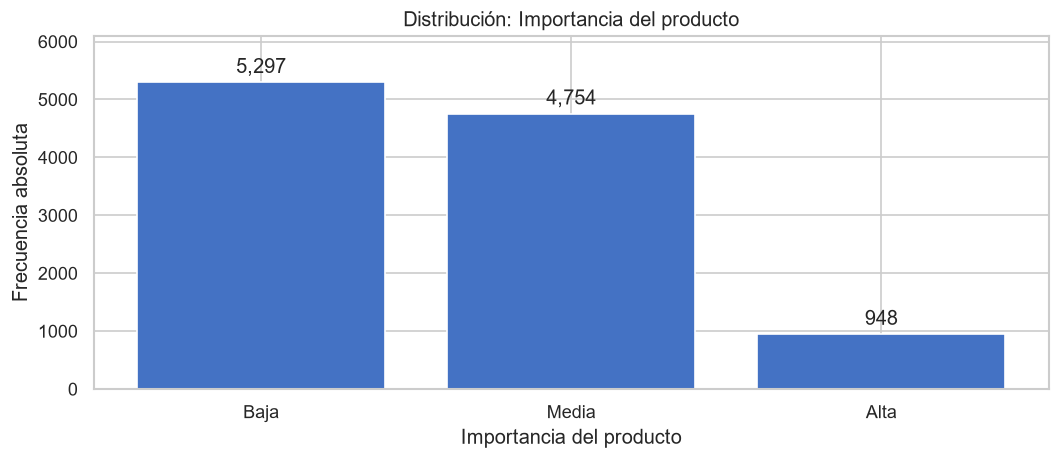

La categoría más frecuente es **Baja**, con **5,297 registros**, equivalentes al **48.16 %** del total.

### Género del cliente

,Frecuencia absoluta,Frecuencia relativa (%)
Categoría,,
Femenino,5545,50.41
Masculino,5454,49.59


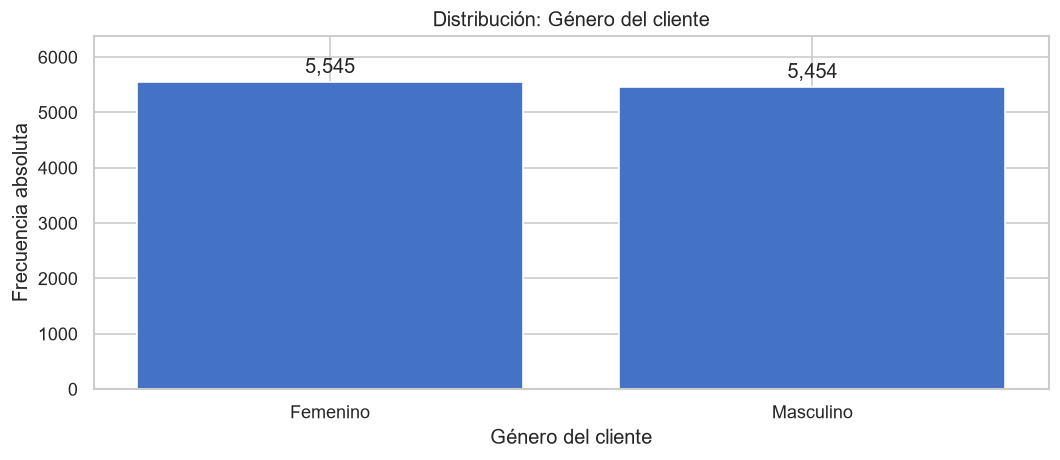

La categoría más frecuente es **Femenino**, con **5,545 registros**, equivalentes al **50.41 %** del total.

### Valoración del cliente

,Frecuencia absoluta,Frecuencia relativa (%)
Categoría,,
1,2235,20.32
2,2165,19.68
3,2239,20.36
4,2189,19.90
5,2171,19.74


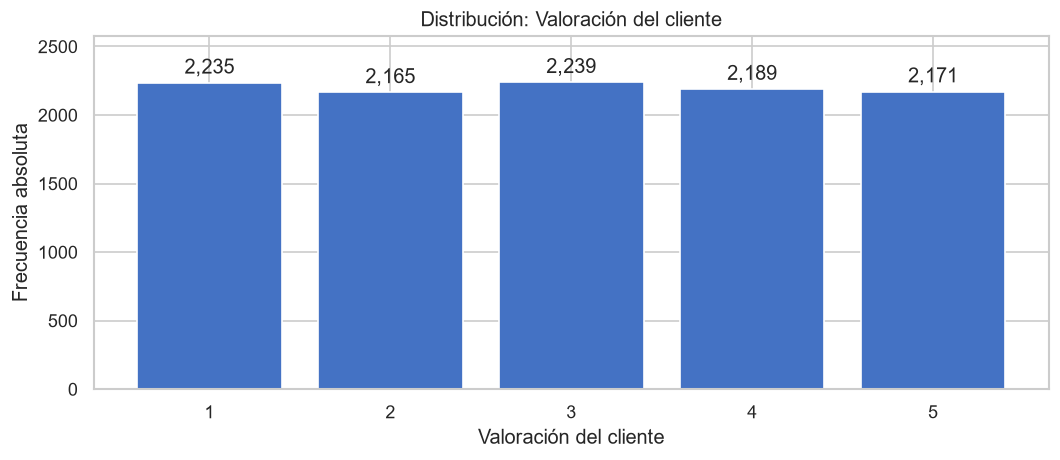

La categoría más frecuente es **3**, con **2,239 registros**, equivalentes al **20.36 %** del total.

### Estado de la entrega

,Frecuencia absoluta,Frecuencia relativa (%)
Categoría,,
Entrega a tiempo,4436,40.33
Entrega fuera de plazo,6563,59.67


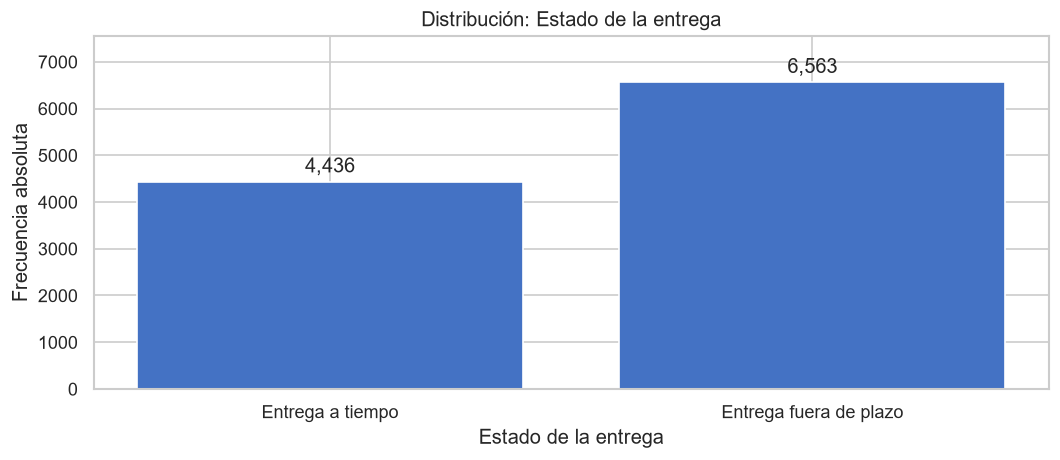

La categoría más frecuente es **Entrega fuera de plazo**, con **6,563 registros**, equivalentes al **59.67 %** del total.

In [18]:
from IPython.display import display, Markdown

CAT = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender", "Customer_rating", "Estado_entrega"]

# Nombres explicativos de las variables.
TITULOS = {
    "Warehouse_block": "Bloque del almacén",
    "Mode_of_Shipment": "Modo de envío",
    "Product_importance": "Importancia del producto",
    "Gender": "Género del cliente",
    "Customer_rating": "Valoración del cliente",
    "Estado_entrega": "Estado de la entrega",
}

# Traducciones y etiquetas para presentar las categorías.
ETIQUETAS = {
    "Warehouse_block": {"A": "Bloque A", "B": "Bloque B", "C": "Bloque C", "D": "Bloque D", "E": "Bloque E", "F": "Bloque F"},
    "Mode_of_Shipment": {"Ship": "Barco", "Flight": "Avión", "Road": "Transporte terrestre"},
    "Product_importance": {"low": "Baja", "medium": "Media", "high": "Alta"},
    "Gender": {"F": "Femenino", "M": "Masculino"},
    "Customer_rating": {1: "1", 2: "2", 3: "3", 4: "4", 5: "5"},
    "Estado_entrega": {"A tiempo": "Entrega a tiempo", "Fuera de plazo": "Entrega fuera de plazo"},
}

# Orden de presentación de las categorías.
ORDENES = {
    "Warehouse_block": ["A", "B", "C", "D", "E", "F"],
    "Mode_of_Shipment": ["Ship", "Flight", "Road"],
    "Product_importance": ["low", "medium", "high"],
    "Gender": ["F", "M"],
    "Customer_rating": [1, 2, 3, 4, 5],
    "Estado_entrega": ["A tiempo", "Fuera de plazo"],
}

for col in CAT:
    titulo = TITULOS[col]

    # Trabajar con una copia de la columna.
    s = df_eda[col].astype("object").fillna("Sin información")
    conteo = s.value_counts()

    # Ordenar las categorías observadas.
    # Conservar también cualquier categoría no prevista.
    orden = [
        categoria
        for categoria in ORDENES[col]
        if categoria in conteo.index
    ]
    adicionales = [
        categoria
        for categoria in conteo.index
        if categoria not in orden
    ]
    conteo = conteo.reindex(orden + adicionales)

    # Aplicar etiquetas solo a la tabla de presentación.
    nombres = [
        ETIQUETAS[col].get(categoria, str(categoria))
        for categoria in conteo.index
    ]

    tabla = pd.DataFrame({
        "Categoría": nombres,
        "Frecuencia absoluta": conteo.to_numpy(),
        "Frecuencia relativa (%)": (
            100 * conteo.to_numpy() / len(df_eda)
        ),
    }).set_index("Categoría")

    # 1. Tabla de frecuencias.
    display(Markdown(f"### {titulo}"))
    display(tabla.round({"Frecuencia relativa (%)": 2}))

    # 2. Gráfico independiente.
    fig, ax = plt.subplots(figsize=(9, 4))

    barras = ax.bar(
        tabla.index,
        tabla["Frecuencia absoluta"],
        color="#4472C4",
    )

    # Etiquetas con la cantidad de registros sobre cada barra.
    ax.bar_label(
        barras,
        labels=[
            f"{int(n):,}"
            for n in tabla["Frecuencia absoluta"]
        ],
        padding=3,
    )

    ax.set_title(f"Distribución: {titulo}")
    ax.set_xlabel(titulo)
    ax.set_ylabel("Frecuencia absoluta")
    ax.margins(y=0.15)

    plt.tight_layout()
    plt.show()

    # 3. Texto con la categoría más frecuente.
    # Si hay empate, mostrar todas las categorías empatadas.
    frecuencia_maxima = tabla["Frecuencia absoluta"].max()
    principales = tabla.index[
        tabla["Frecuencia absoluta"].eq(frecuencia_maxima)
    ].tolist()

    porcentaje = 100 * frecuencia_maxima / len(df_eda)
    categorias_texto = ", ".join(principales)

    if len(principales) == 1:
        texto = (
            f"La categoría más frecuente es **{categorias_texto}**, "
            f"con **{int(frecuencia_maxima):,} registros**, "
            f"equivalentes al **{porcentaje:.2f} %** del total."
        )
    else:
        texto = (
            f"Las categorías más frecuentes son **{categorias_texto}**, "
            f"cada una con **{int(frecuencia_maxima):,} registros**, "
            f"equivalentes al **{porcentaje:.2f} %** del total."
        )

    display(Markdown(texto))